# Part 1: Helping functions and data loading

In [26]:
# Do not modify this cell, this is only for plotting the clusters
# NOTE: I modified the cluster to plot centers.
import matplotlib.pyplot as plt

def plot_clustering_result(X, labels, centers=None, title=None):
    title = title or "clustering result"
    fig, ax = plt.subplots(figsize=(6, 5))
    noise = labels == -1
    if noise.any():
        ax.scatter(X[noise, 0], X[noise, 1], s=18, marker="x", c="k", alpha=0.9, label="noise (-1)")
    for k in sorted(set(labels) - {-1}):
        ax.scatter(X[labels == k, 0], X[labels == k, 1], s=18, alpha=0.9, label=f"cluster {k}")

    if centers is not None and centers.any():
        ax.scatter(centers[:,0], centers[:,1], s=18, marker="D", c="k", alpha=0.9, label="center")

    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(title)
    ax.legend(loc="best", frameon=True)
    ax.grid(True)
    plt.show()

In [58]:
from IPython.display import display
from IPython.display import Markdown

def report(string):
    display(Markdown(string))

class Table:
    def tableHeader(self):
        doc = "| EPS | MIN_POINTS | #Clusters | #Noise |\n"
        doc += "| --- | --- | --- | --- |\n"
        return doc

    def __init__(self):
        self.prev_algo = None
        self.prev_hyper = None
        self.prev_value = None
        self.doc = self.tableHeader()

    def addRow(self, eps=None, minPoints=None, num_clusters=None, num_noise=None):
        rows = ""
        rows += f"| {eps:.4g} | {minPoints} | {num_clusters} | {num_noise} |\n"
        self.doc = self.doc + rows
        return self

    def report(self):
        report(self.doc)


enable_debug = False

def debug(string):
    if (enable_debug):
        print(string)


In [5]:
# loading data
import numpy as np

# part1_data.npz contains X.npy and Y.npy. the array indexing loads the individual file.
X = np.load("part1_data.npz")["X"]

[[-8.48190163 -4.36549386]
 [-8.21067118 -4.44820716]
 [ 4.84501768 -0.06097765]
 ...
 [ 2.64756747  0.42369152]
 [-0.16090199 -0.34245516]
 [-3.52352076 -2.6337433 ]]


# Part 2: Clustering
## <span style="color: red; font-weight: 700;">Your answers should start here!</span>

No new code is required. Only change the variables already in the notebook and re-run the cells to produce your answers!

## K-means experiments

## Hyperparameter Discovery

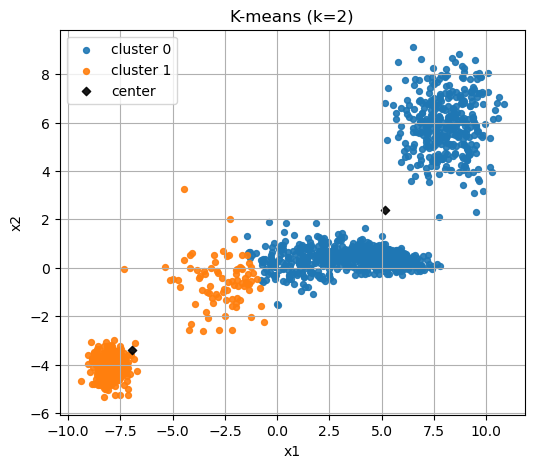

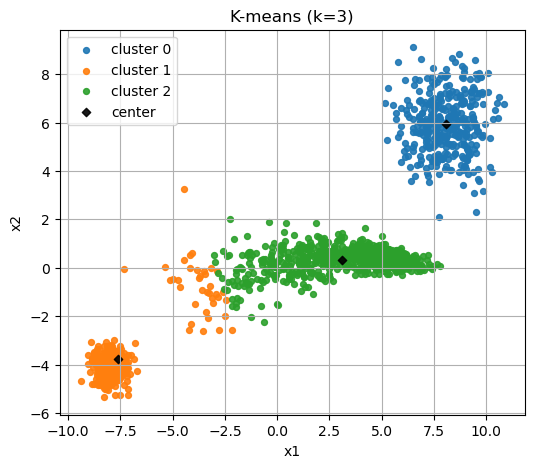

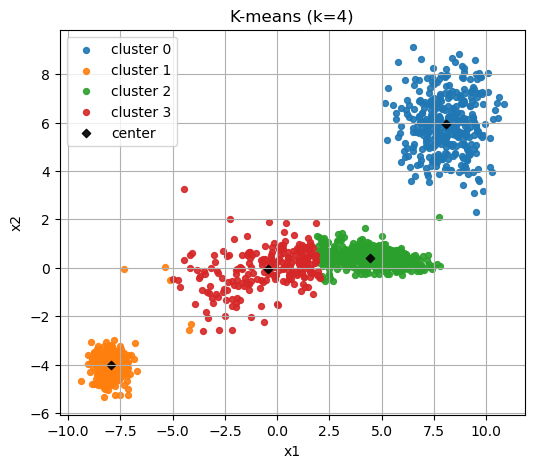

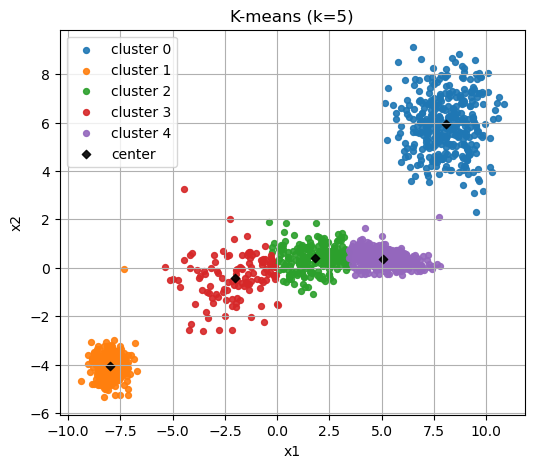

In [24]:
from sklearn.cluster import KMeans

# Number of clusters
for K in [ 2,3,4,5] :
    # K = 10

    # Fit K-means and get labels
    km = KMeans(n_clusters=K, random_state=42, n_init="auto").fit(X)
    labels = km.labels_
    centers = km.cluster_centers_
    # ploting data
    plot_clustering_result(X, labels, centers=centers, title=f"K-means (k={K})")


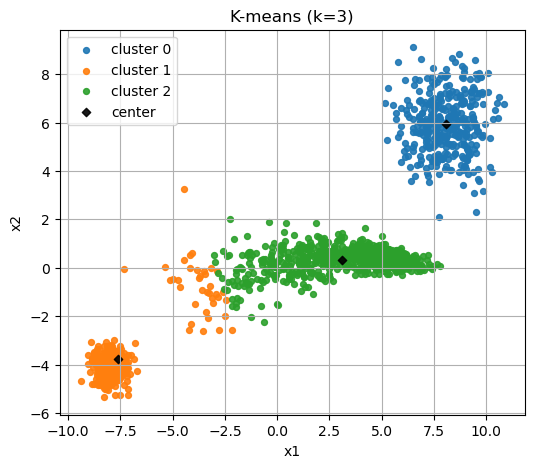

In [69]:
from sklearn.cluster import KMeans

# Number of clusters
for K in [3] :
    # Fit K-means and get labels
    km = KMeans(n_clusters=K, random_state=42, n_init="auto").fit(X)
    labels = km.labels_
    centers = km.cluster_centers_
    # ploting data
    plot_clustering_result(X, labels, centers=centers, title=f"K-means (k={K})")


### K-means Answers

The value for K which best matches the visible clusters is 3. This value for K results the central cluster being blended with the bottom left cluster. K-means creates circular clusters, and the central cluster cannot be grown any more without taking members from the top-right cluster. This requires the bottom left cluster to grow to take the less dense component of the central cluster.

However, the value of K which is the most useful is 5. If we are using K-means to apply a treatment to a group, we can apply the same treatment to the central 3 clusters and have a result which is more accurate than K=3. We increase the resolution to make up for the central cluster's non-circular shape.

## DBSCAN experiments

### Hyperparameter Search

In [70]:
import numpy as np
from sklearn.cluster import DBSCAN

# Hyperparameter searching is best done computationally. So, compute away!
hyperResults = Table()

for eps in np.arange(0.1, 2., 0.1):
    for min_points in range(3, 20):
        labels = DBSCAN(eps=eps, min_samples=min_points).fit_predict(X)
        num_noise = (labels==-1).sum()
        num_clusters=len(set(labels) - {-1})
        # We know num_clusters is 3, so use that.
        # It is a big table, only output reasonable values for selection.
        if num_clusters == 3 and num_noise <= 4:
            hyperResults.addRow(eps=eps, minPoints=min_points, num_clusters=num_clusters, num_noise=num_noise)

hyperResults.report()

| EPS | MIN_POINTS | #Clusters | #Noise |
| --- | --- | --- | --- |
| 0.8 | 3 | 3 | 4 |
| 0.9 | 3 | 3 | 3 |
| 0.9 | 4 | 3 | 3 |
| 0.9 | 5 | 3 | 3 |
| 0.9 | 6 | 3 | 3 |
| 0.9 | 7 | 3 | 4 |
| 1 | 3 | 3 | 3 |
| 1 | 4 | 3 | 3 |
| 1 | 5 | 3 | 3 |
| 1 | 6 | 3 | 3 |
| 1 | 7 | 3 | 4 |
| 1.1 | 3 | 3 | 3 |
| 1.1 | 4 | 3 | 3 |
| 1.1 | 5 | 3 | 3 |
| 1.1 | 6 | 3 | 3 |
| 1.1 | 7 | 3 | 3 |
| 1.1 | 8 | 3 | 3 |
| 1.1 | 9 | 3 | 4 |
| 1.1 | 10 | 3 | 4 |
| 1.1 | 11 | 3 | 4 |
| 1.2 | 3 | 3 | 3 |
| 1.2 | 4 | 3 | 3 |
| 1.2 | 5 | 3 | 3 |
| 1.2 | 6 | 3 | 3 |
| 1.2 | 7 | 3 | 3 |
| 1.2 | 8 | 3 | 3 |
| 1.2 | 9 | 3 | 3 |
| 1.2 | 10 | 3 | 3 |
| 1.2 | 11 | 3 | 3 |
| 1.2 | 12 | 3 | 3 |
| 1.2 | 13 | 3 | 4 |
| 1.3 | 3 | 3 | 3 |
| 1.3 | 4 | 3 | 3 |
| 1.3 | 5 | 3 | 3 |
| 1.3 | 6 | 3 | 3 |
| 1.3 | 7 | 3 | 3 |
| 1.3 | 8 | 3 | 3 |
| 1.3 | 9 | 3 | 3 |
| 1.3 | 10 | 3 | 3 |
| 1.3 | 11 | 3 | 3 |
| 1.3 | 12 | 3 | 3 |
| 1.3 | 13 | 3 | 3 |
| 1.3 | 14 | 3 | 3 |
| 1.3 | 15 | 3 | 3 |
| 1.3 | 16 | 3 | 3 |
| 1.3 | 17 | 3 | 3 |
| 1.3 | 18 | 3 | 4 |
| 1.3 | 19 | 3 | 4 |
| 1.4 | 3 | 3 | 3 |
| 1.4 | 4 | 3 | 3 |
| 1.4 | 5 | 3 | 3 |
| 1.4 | 6 | 3 | 3 |
| 1.4 | 7 | 3 | 3 |
| 1.4 | 8 | 3 | 3 |
| 1.4 | 9 | 3 | 3 |
| 1.4 | 10 | 3 | 3 |
| 1.4 | 11 | 3 | 3 |
| 1.4 | 12 | 3 | 3 |
| 1.4 | 13 | 3 | 3 |
| 1.4 | 14 | 3 | 3 |
| 1.4 | 15 | 3 | 3 |
| 1.4 | 16 | 3 | 3 |
| 1.4 | 17 | 3 | 3 |
| 1.4 | 18 | 3 | 3 |
| 1.4 | 19 | 3 | 3 |
| 1.5 | 3 | 3 | 3 |
| 1.5 | 4 | 3 | 3 |
| 1.5 | 5 | 3 | 3 |
| 1.5 | 6 | 3 | 3 |
| 1.5 | 7 | 3 | 3 |
| 1.5 | 8 | 3 | 3 |
| 1.5 | 9 | 3 | 3 |
| 1.5 | 10 | 3 | 3 |
| 1.5 | 11 | 3 | 3 |
| 1.5 | 12 | 3 | 3 |
| 1.5 | 13 | 3 | 3 |
| 1.5 | 14 | 3 | 3 |
| 1.5 | 15 | 3 | 3 |
| 1.5 | 16 | 3 | 3 |
| 1.5 | 17 | 3 | 3 |
| 1.5 | 18 | 3 | 3 |
| 1.5 | 19 | 3 | 3 |
| 1.6 | 3 | 3 | 2 |
| 1.6 | 4 | 3 | 2 |
| 1.6 | 5 | 3 | 2 |
| 1.6 | 6 | 3 | 2 |
| 1.6 | 7 | 3 | 2 |
| 1.6 | 8 | 3 | 2 |
| 1.6 | 9 | 3 | 2 |
| 1.6 | 10 | 3 | 2 |
| 1.6 | 11 | 3 | 2 |
| 1.6 | 12 | 3 | 2 |
| 1.6 | 13 | 3 | 2 |
| 1.6 | 14 | 3 | 2 |
| 1.6 | 15 | 3 | 2 |
| 1.6 | 16 | 3 | 2 |
| 1.6 | 17 | 3 | 2 |
| 1.6 | 18 | 3 | 2 |
| 1.6 | 19 | 3 | 2 |
| 1.7 | 4 | 3 | 2 |
| 1.7 | 5 | 3 | 2 |
| 1.7 | 6 | 3 | 2 |
| 1.7 | 7 | 3 | 2 |
| 1.7 | 8 | 3 | 2 |
| 1.7 | 9 | 3 | 2 |
| 1.7 | 10 | 3 | 2 |
| 1.7 | 11 | 3 | 2 |
| 1.7 | 12 | 3 | 2 |
| 1.7 | 13 | 3 | 2 |
| 1.7 | 14 | 3 | 2 |
| 1.7 | 15 | 3 | 2 |
| 1.7 | 16 | 3 | 2 |
| 1.7 | 17 | 3 | 2 |
| 1.7 | 18 | 3 | 2 |
| 1.7 | 19 | 3 | 2 |
| 1.8 | 9 | 3 | 2 |
| 1.8 | 10 | 3 | 2 |
| 1.8 | 11 | 3 | 2 |
| 1.8 | 12 | 3 | 2 |
| 1.8 | 13 | 3 | 2 |
| 1.8 | 14 | 3 | 2 |
| 1.8 | 15 | 3 | 2 |
| 1.8 | 16 | 3 | 2 |
| 1.8 | 17 | 3 | 2 |
| 1.8 | 18 | 3 | 2 |
| 1.8 | 19 | 3 | 2 |
| 1.9 | 10 | 3 | 2 |
| 1.9 | 11 | 3 | 2 |
| 1.9 | 12 | 3 | 2 |
| 1.9 | 13 | 3 | 2 |
| 1.9 | 14 | 3 | 2 |
| 1.9 | 15 | 3 | 2 |
| 1.9 | 16 | 3 | 2 |
| 1.9 | 17 | 3 | 2 |
| 1.9 | 18 | 3 | 2 |
| 1.9 | 19 | 3 | 2 |


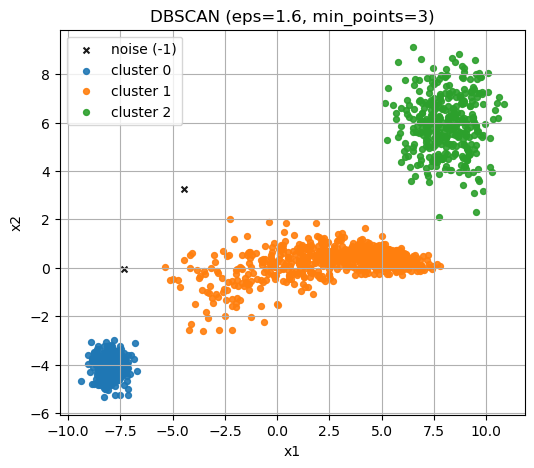

In [71]:
from sklearn.cluster import DBSCAN

# 0.8, 3 is first working value.
# 1.6, 3 is best.
EPS = 0.2  # epsilon=neighbourhood radius
MIN_POINTS = 5  # min_samples = min_points

EPS = 1.6  # epsilon=neighbourhood radius
MIN_POINTS = 3  # min_samples = min_points

# Fit DBSCAN and get labels
labels = DBSCAN(eps=EPS, min_samples=MIN_POINTS).fit_predict(X)

#labels: -1 = noise; 0,1,2,... = cluster IDs

# Example usage:
plot_clustering_result(X, labels, title=f"DBSCAN (eps={EPS}, min_points={MIN_POINTS})")


### DBSCAN Answers

EPS = 1.6
MIN_POINTS = 3

There are many pairs of values which result in this number of clusters and this amount of noise. This was the earliest on in my search. Any 0.8 <= EPS <= 1.9 will produce 3 clusters. EPS = 2.0 allows the central cluster to jump across to the top right. There is no computational advantage to different EPS/MIN_POINTS values. The EPS value allows the central cluster to reach the weakly joined values on the left, and the single value between the middle and top-right to be labeled.